# Exploratory Data Analysis (EDA) on Pima Indians Diabetes Dataset


## Giới thiệu
Bộ dữ liệu Pima Indians Diabetes chứa thông tin y tế của phụ nữ người Mỹ gốc Pima, nhằm dự đoán khả năng mắc bệnh tiểu đường dựa trên các chỉ số sinh học.

Mục tiêu của bài toán là xây dựng mô hình Machine Learning để phân loại nguy cơ tiểu đường (Outcome = 1 hoặc 0) dựa trên các biến như Glucose, Insulin, BMI, Age, v.v.

Trước khi huấn luyện mô hình, chúng ta thực hiện bước phân tích khám phá dữ liệu (EDA) để hiểu rõ cấu trúc, phân bố, và mối liên hệ giữa các biến.


## Khởi tạo thư viện cần thiết

Trong bước phân tích dữ liệu khám phá (EDA), chúng ta sử dụng các thư viện phổ biến của Python để xử lý, trực quan hóa và phân tích dữ liệu:

- `pandas`: xử lý dữ liệu dạng bảng (DataFrame)
- `numpy`: hỗ trợ tính toán số học
- `matplotlib.pyplot`: vẽ biểu đồ cơ bản
- `seaborn`: trực quan hóa nâng cao, hỗ trợ biểu đồ đẹp và dễ đọc


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Khám phá dữ liệu

### Load dữ liệu

Chúng ta bắt đầu bằng cách tải bộ dữ liệu Pima Indians Diabetes từ file `diabetes.csv` vào một DataFrame sử dụng thư viện `pandas`.


In [17]:
# --- 1. Load Data ---
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Machine_learning/Pima/dataset/diabetes.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Thông tin tổng quan về dữ liệu
## 🩺 Thông tin bộ dữ liệu: Pima Indians Diabetes

- **Số dòng:** 768  
- **Số cột:** 9  
- **Biến mục tiêu:** `Outcome`  
  - `0`: Không mắc tiểu đường  
  - `1`: Mắc tiểu đường (268/768 mẫu)

### 🔹 Các biến đặc trưng (Features)

| Tên biến | Mô tả |
|-----------|-------|
| `Pregnancies` | Số lần mang thai |
| `Glucose` | Mức đường huyết sau 2 giờ trong xét nghiệm dung nạp glucose |
| `BloodPressure` | Huyết áp tâm trương (mm Hg) |
| `SkinThickness` | Độ dày nếp gấp da (mm) |
| `Insulin` | Nồng độ insulin huyết thanh sau 2 giờ (μU/ml) |
| `BMI` | Chỉ số khối cơ thể = cân nặng (kg) / (chiều cao (m))² |
| `DiabetesPedigreeFunction` | Mức độ di truyền bệnh tiểu đường |
| `Age` | Tuổi của bệnh nhân |


In [18]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét: ** Không có giá trị thiếu (null) trong bất kỳ cột nào → dữ liệu đầy đủ, không cần xử lý missing values.

In [20]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Kiểm tra dữ liệu thiếu và giá trị bằng 0

Một số cột trong bộ dữ liệu có thể chứa giá trị bằng 0, vốn không hợp lý về mặt y học (ví dụ: Glucose = 0).  
Ta sẽ thay thế các giá trị 0 bằng `NaN` để xử lý như dữ liệu thiếu, và kiểm tra số lượng missing values trước khi xử lý.


In [22]:
import seaborn as sns
df.replace(0, np.nan).isnull().sum().sort_values()


,0
DiabetesPedigreeFunction,0
Age,0
Glucose,5
BMI,11
BloodPressure,35
Pregnancies,111
SkinThickness,227
Insulin,374
Outcome,500


### 📋 Tổng hợp nhận xét

Trong bộ dữ liệu có tổng cộng **768 dòng** và **9 cột**. Khi kiểm tra các giá trị bằng **0**, ta thu được bảng sau:

| Cột                          | Số giá trị bằng 0 | Nhận xét                                                                                                                            |
| ---------------------------- | ----------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **DiabetesPedigreeFunction** | 0                 |  Không có giá trị 0 – hợp lý.                                                                                                      |
| **Age**                      | 0                 |  Không có giá trị 0 – hợp lý (tuổi không thể 0).                                                                                   |
| **Glucose**                  | 5                 |  Có 5 giá trị 0 — *không hợp lý*, vì mức đường huyết không thể bằng 0. Những giá trị này nên được xem là **thiếu dữ liệu (NaN)**. |
| **BMI**                      | 11                |  Có 11 giá trị 0 — *không hợp lý*, vì chỉ số BMI không thể bằng 0. Cần thay bằng **NaN**.                                         |
| **BloodPressure**            | 35                |  Có 35 giá trị 0 — *không hợp lý*, vì huyết áp không thể bằng 0. Nên xử lý như **missing values**.                                |
| **Pregnancies**              | 111               |  Hợp lý — có thể có người **chưa từng mang thai**.                                                                                 |
| **SkinThickness**            | 227               |  Rất nhiều giá trị 0 — *không hợp lý*, vì độ dày da không thể bằng 0. Đây là **thiếu dữ liệu**.                                   |
| **Insulin**                  | 374               |  Rất nhiều giá trị 0 — *không hợp lý*, vì mức insulin không thể bằng 0. Đây là **missing values**.                                |
| **Outcome**                  | 500               |  Hợp lý — `0` nghĩa là **không bị tiểu đường**.                                                                                    |

---

### 🧩 Kết luận

- Hai cột **`Pregnancies`** và **`Outcome`** có thể chứa giá trị **0 hợp lệ**.  
  - `Pregnancies = 0`: người phụ nữ chưa từng mang thai.  
  - `Outcome = 0`: người không mắc bệnh tiểu đường.

- Các cột **`Glucose`**, **`BloodPressure`**, **`SkinThickness`**, **`Insulin`**, và **`BMI`** có giá trị **0 không hợp lý về mặt sinh học**.  
  → Cần **thay các giá trị 0 bằng NaN** để xử lý thiếu dữ liệu trước khi huấn luyện mô hình.

- Đặc biệt, **`SkinThickness`** và **`Insulin`** có **tỷ lệ thiếu dữ liệu cao**, cần được chú ý khi tiền xử lý.


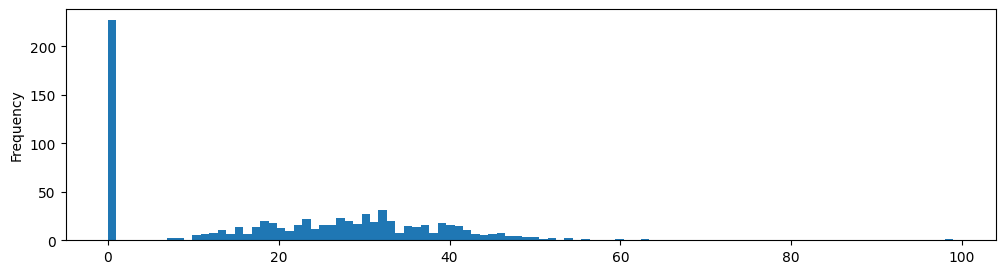

In [26]:
df.SkinThickness.plot.hist(bins=100,figsize=(12, 3));


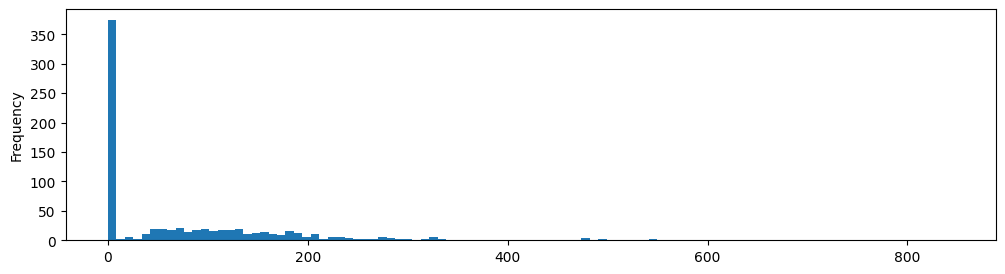

In [27]:
df.Insulin.plot.hist(bins=100,figsize=(12, 3));

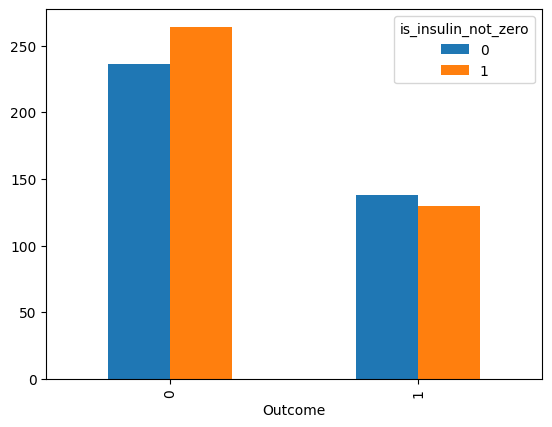

In [28]:
df_temp = df.copy()
df_temp['is_insulin_not_zero'] = (df_temp.Insulin != 0).astype(int)
df_temp.groupby(['Outcome', 'is_insulin_not_zero'])\
    .count()[['Insulin']]\
    .reset_index()\
    .pivot(index='Outcome', columns='is_insulin_not_zero', values='Insulin')\
    .plot.bar();

Nhận xét: Giá trị bằng 0 và khác 0 của Insulin ít ảnh hưởng đến Outcome

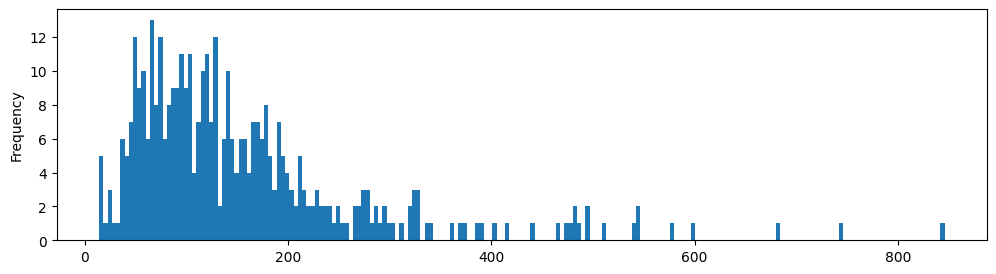

In [32]:
df.Insulin.replace(0, np.nan).plot.hist(bins=200,figsize=(12, 3));

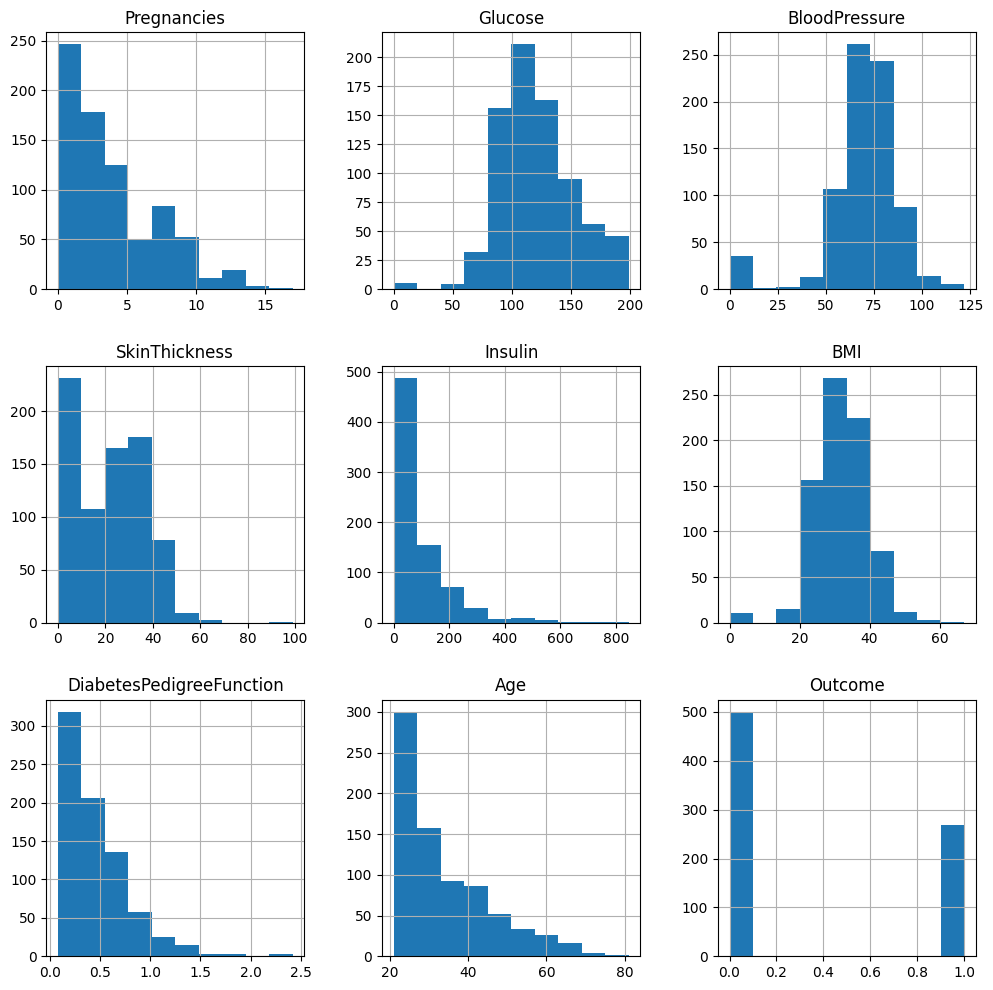

In [33]:
df.hist(figsize = (12, 12));

In [34]:
df[(df.Age > 0) & (df.Age < 21)].shape[0]

0

Nhận xét: Tuổi trong tập dữ liệu đều lớn hơn 21 -> Dữ liệu có thể đang bị sai hoặc thiếu

In [36]:


df.replace(0, np.nan).describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,657.0,4.5,3.2,1.0,2.0,4.0,7.0,17.0
Glucose,763.0,121.7,30.5,44.0,99.0,117.0,141.0,199.0
BloodPressure,733.0,72.4,12.4,24.0,64.0,72.0,80.0,122.0
SkinThickness,541.0,29.2,10.5,7.0,22.0,29.0,36.0,99.0
Insulin,394.0,155.5,118.8,14.0,76.2,125.0,190.0,846.0
BMI,757.0,32.5,6.9,18.2,27.5,32.3,36.6,67.1
DiabetesPedigreeFunction,768.0,0.5,0.3,0.1,0.2,0.4,0.6,2.4
Age,768.0,33.2,11.8,21.0,24.0,29.0,41.0,81.0
Outcome,268.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


### Kiểm tra độ cân bằng của OutCome

/tmp/ipython-input-321582428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


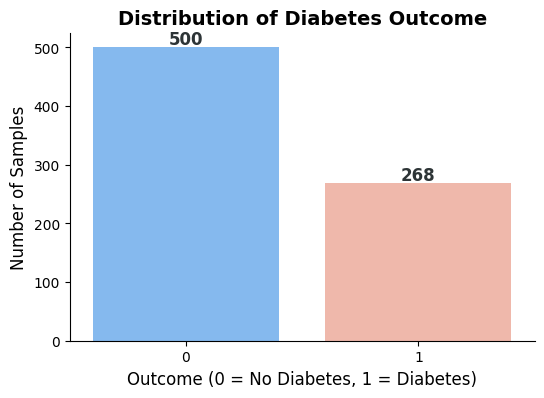

In [23]:


# Đếm số lượng mỗi lớp trong Outcome
count = df['Outcome'].value_counts()

# Tạo biểu đồ cột
plt.figure(figsize=(6,4))
sns.barplot(
    x=count.index,
    y=count.values,
    palette=['#74b9ff', '#fab1a0']  # xanh pastel & cam nhạt
)

# Thêm nhãn số lên trên cột
for i, v in enumerate(count.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold', color='#2d3436')

# Tiêu đề và nhãn trục
plt.title('Distribution of Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Tắt khung viền xám cho gọn
sns.despine()

# Hiển thị biểu đồ
plt.show()


** Nhận xét: **
Biểu đồ cho thấy lớp 0 (không tiểu đường) có nhiều mẫu hơn lớp 1 (có tiểu đường), tuy nhiên sự chênh lệch không đáng kể (500 so với 268).
Bộ dữ liệu chỉ hơi mất cân bằng nhẹ nhưng không đáng kể

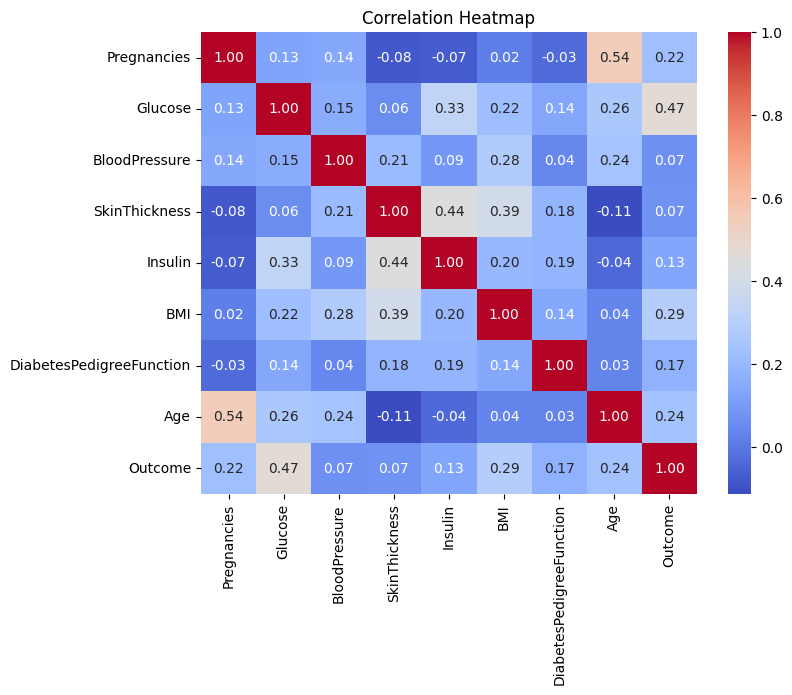

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


Nhận xét về ma trận tương quan

Mức tương quan cao nhất với biến mục tiêu (Outcome) là:

🩸 Glucose (0.47) → tương quan dương mạnh nhất → người có mức glucose cao có khả năng mắc tiểu đường cao hơn.

🧍‍♀️ BMI (0.29) → người có chỉ số khối cơ thể cao cũng dễ bị tiểu đường.

👶 Age (0.24) → tuổi càng cao, nguy cơ mắc bệnh càng lớn.

🤰 Pregnancies (0.22) → số lần mang thai cao có thể liên quan nhẹ đến nguy cơ tiểu đường.
**Giữa các biến đầu vào với nhau, đáng chú ý:**

SkinThickness ↔ Insulin (0.44) có tương quan khá cao → có thể phản ánh cùng yếu tố sinh lý.

Pregnancies ↔ Age (0.54) → hợp lý, vì người lớn tuổi thường có nhiều lần mang thai hơn.

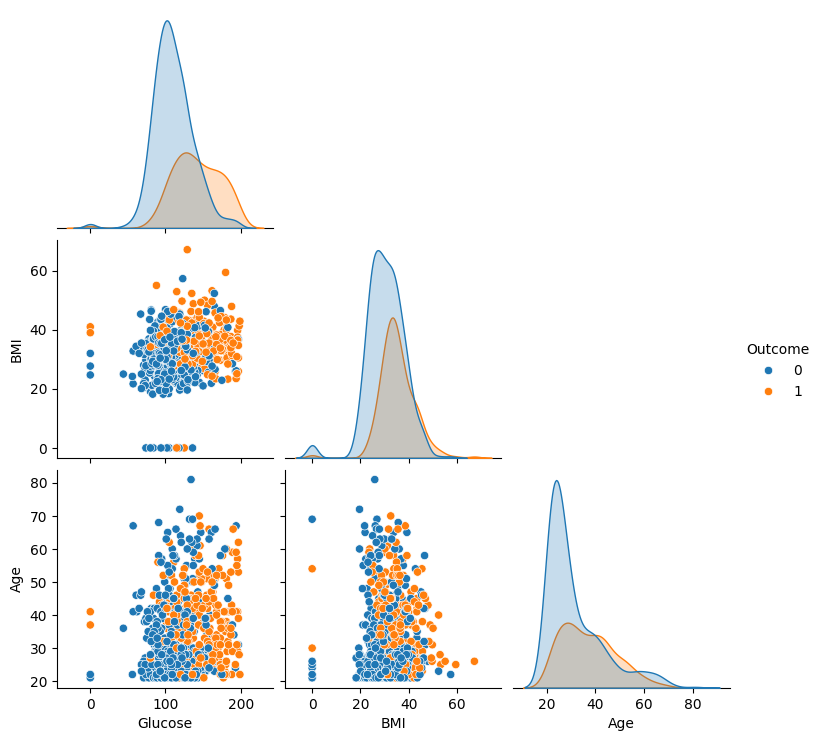

In [25]:
import seaborn as sns
sns.pairplot(df[['Glucose','BMI','Age','Outcome']], hue='Outcome', diag_kind='kde', corner=True)
